In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load processed wildfire dataset
print('Loading wildfire dataset...')
df = pd.read_csv('../data/wildfires/wildfires_processed.csv')

print(f'Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nTarget distribution:')
print(df['FIRE_SIZE_CLASS'].value_counts())

Loading wildfire dataset...
Shape: (1880465, 6)
Columns: ['LATITUDE', 'LONGITUDE', 'FIRE_YEAR', 'STAT_CAUSE_CODE', 'DISCOVERY_DOY', 'FIRE_SIZE_CLASS']

Target distribution:
FIRE_SIZE_CLASS
B    939376
A    666919
C    220077
D     28427
E     14107
F      7786
G      3773
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import time


# Encode target
le = LabelEncoder()
df['TARGET'] = le.fit_transform(df['FIRE_SIZE_CLASS'])

# Features and target
X = df[['LATITUDE', 'LONGITUDE', 'FIRE_YEAR', 'STAT_CAUSE_CODE', 'DISCOVERY_DOY']]
y = df['TARGET']

# Use sample for speed — 200K records is enough
X_sample, _, y_sample, _ = train_test_split(X, y, train_size=200000, random_state=42, stratify=y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

print(f'Training set: {X_train.shape}')
print(f'Test set: {X_test.shape}')
print(f'Classes: {le.classes_}')
print('Ready to train')

Training set: (160000, 5)
Test set: (40000, 5)
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G']
Ready to train


In [3]:
results = {}

# 1. Random Forest
print('Training Random Forest...')
start = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)
rf_time = time.time() - start
rf_f1 = f1_score(y_test, rf.predict(X_test), average='weighted')
results['Random Forest'] = {'f1': rf_f1, 'time': rf_time}
print(f'   F1: {rf_f1:.4f} | Time: {rf_time:.1f}s')

# 2. XGBoost
print('Training XGBoost...')
start = time.time()
xgb = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0)
xgb.fit(X_train, y_train)
xgb_time = time.time() - start
xgb_f1 = f1_score(y_test, xgb.predict(X_test), average='weighted')
results['XGBoost'] = {'f1': xgb_f1, 'time': xgb_time}
print(f'   F1: {xgb_f1:.4f} | Time: {xgb_time:.1f}s')

# 3. LightGBM
print('Training LightGBM...')
start = time.time()
lgbm = LGBMClassifier(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_time = time.time() - start
lgbm_f1 = f1_score(y_test, lgbm.predict(X_test), average='weighted')
results['LightGBM'] = {'f1': lgbm_f1, 'time': lgbm_time}
print(f'   F1: {lgbm_f1:.4f} | Time: {lgbm_time:.1f}s')


print('Training CatBoost (Yandex)...')
start = time.time()
cat = CatBoostClassifier(iterations=100, random_seed=42, verbose=0, auto_class_weights='Balanced')
cat.fit(X_train, y_train)
cat_time = time.time() - start
cat_f1 = f1_score(y_test, cat.predict(X_test), average='weighted')
results['CatBoost'] = {'f1': cat_f1, 'time': cat_time}
print(f'CatBoost F1: {cat_f1:.4f} | Time: {cat_time:.1f}s')

# Final results
print('\n' + '='*40)
print(f'{"MODEL":<20} {"F1 SCORE":>10} {"TIME":>8}')
print('='*40)
for model, r in results.items():
    marker = ' <-- winner' if model == max(results, key=lambda x: results[x]['f1']) else ''
    print(f'{model:<20} {r["f1"]:>10.4f} {r["time"]:>7.1f}s{marker}')
print('='*40)

Training Random Forest...
   F1: 0.5881 | Time: 4.0s
Training XGBoost...
   F1: 0.5864 | Time: 1.4s
Training LightGBM...
   F1: 0.5794 | Time: 2.5s
Training CatBoost (Yandex)...
CatBoost F1: 0.4599 | Time: 1.7s

MODEL                  F1 SCORE     TIME
Random Forest            0.5881     4.0s <-- winner
XGBoost                  0.5864     1.4s
LightGBM                 0.5794     2.5s
CatBoost                 0.4599     1.7s


Computing SHAP values...
SHAP values computed


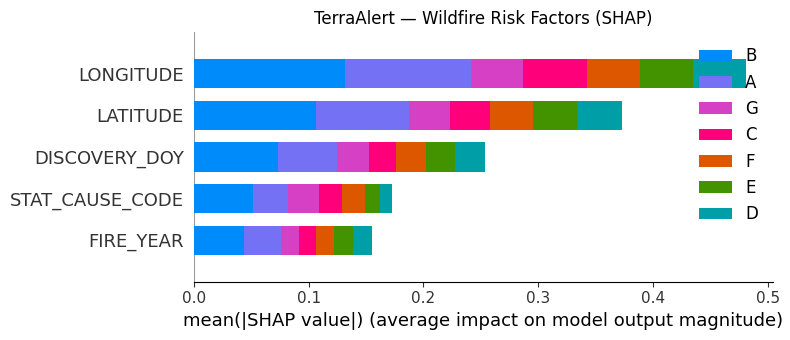

In [4]:
import shap
import matplotlib.pyplot as plt

# Compute SHAP values first
print('Computing SHAP values...')
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test[:500])
print('SHAP values computed')

# Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test[:500],
    feature_names=['LATITUDE', 'LONGITUDE', 'FIRE_YEAR',
                   'STAT_CAUSE_CODE', 'DISCOVERY_DOY'],
    class_names=['A','B','C','D','E','F','G'],
    plot_type='bar',
    show=False
)
plt.title('TerraAlert — Wildfire Risk Factors (SHAP)')
plt.tight_layout()
plt.savefig('../data/wildfires/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
import pickle
import os

os.makedirs('../models', exist_ok=True)

# Save winner
with open('../models/rf_wildfire.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Save all for comparison
with open('../models/xgb_wildfire.pkl', 'wb') as f:
    pickle.dump(xgb, f)
with open('../models/lgbm_wildfire.pkl', 'wb') as f:
    pickle.dump(lgbm, f)
with open('../models/catboost_wildfire.pkl', 'wb') as f:
    pickle.dump(cat, f)

print('All models saved')
print('Winner: Random Forest — rf_wildfire.pkl')

All models saved
Winner: Random Forest — rf_wildfire.pkl


WILDFIRE MODEL — FULL EVALUATION

1. PER CLASS METRICS (Random Forest):
              precision    recall  f1-score   support

           A       0.65      0.63      0.64     14186
           B       0.62      0.76      0.68     19982
           C       0.34      0.11      0.16      4681
           D       0.17      0.02      0.04       605
           E       0.25      0.02      0.03       300
           F       0.17      0.02      0.03       166
           G       0.06      0.01      0.02        80

    accuracy                           0.62     40000
   macro avg       0.32      0.22      0.23     40000
weighted avg       0.58      0.62      0.59     40000



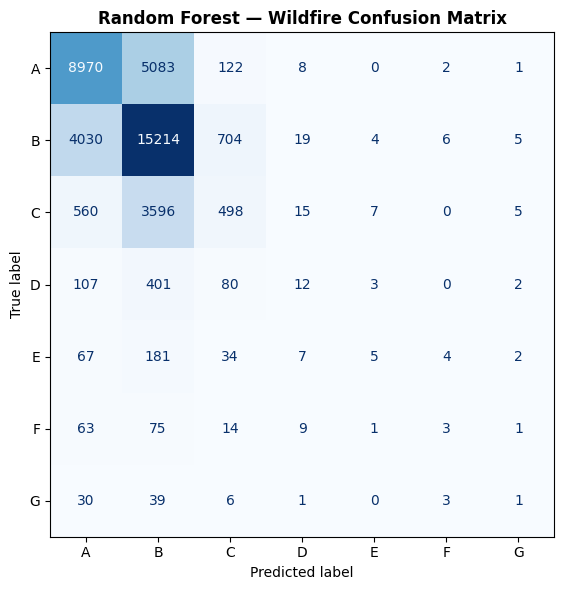


2. CROSS VALIDATION (5-fold):
  Fold scores: [np.float64(0.5933), np.float64(0.5861), np.float64(0.5921), np.float64(0.5919), np.float64(0.5862)]
  Mean F1:     0.5899
  Std Dev:     0.0031
  Test F1:     0.5881
  Conclusion: Consistent — test score is reliable

3. ERROR ANALYSIS:

Class     Precision     Recall         F1    Support Notes
----------------------------------------------------------------------
A            0.6487     0.6323     0.6404      14186
B            0.6187     0.7614     0.6827      19982
C            0.3416     0.1064     0.1622       4681
D            0.1690     0.0198     0.0355        605
E            0.2500     0.0167     0.0312        300 ← rare class, imbalanced
F            0.1667     0.0181     0.0326        166 ← rare class, imbalanced
G            0.0588     0.0125     0.0206         80 ← rare class, imbalanced

4. KEY FINDINGS:
Class B (most common — 50% of data):
  Precision=0.6187, Recall=0.7614
Class G (catastrophic — 0.2% of data):
  Precision=

In [9]:
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

print('='*55)
print('WILDFIRE MODEL — FULL EVALUATION')
print('='*55)

class_names = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
y_pred_rf = rf.predict(X_test)

# 1. Per class metrics
print('\n1. PER CLASS METRICS (Random Forest):')
print(classification_report(y_test, y_pred_rf, target_names=class_names))

# 2. Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest — Wildfire Confusion Matrix',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/wildfires/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Cross Validation
print('\n2. CROSS VALIDATION (5-fold):')
cv_scores = cross_val_score(
    rf, X_train, y_train,
    cv=5, scoring='f1_weighted', n_jobs=-1
)
print(f'  Fold scores: {[round(s,4) for s in cv_scores]}')
print(f'  Mean F1:     {cv_scores.mean():.4f}')
print(f'  Std Dev:     {cv_scores.std():.4f}')
print(f'  Test F1:     {rf_f1:.4f}')
if abs(cv_scores.mean() - rf_f1) < 0.02:
    print('  Conclusion: Consistent — test score is reliable')
else:
    print('  Conclusion: Some variance — model may need more data')

# 4. Error analysis
print('\n3. ERROR ANALYSIS:')
report = classification_report(y_test, y_pred_rf,
                                target_names=class_names,
                                output_dict=True)
print(f'\n{"Class":<8} {"Precision":>10} {"Recall":>10} {"F1":>10} {"Support":>10} {"Notes"}')
print('-'*70)
for cls in class_names:
    r = report[cls]
    flag = ' ← rare class, imbalanced' if int(r['support']) < 500 else ''
    print(f'{cls:<8} {r["precision"]:>10.4f} {r["recall"]:>10.4f} {r["f1-score"]:>10.4f} {int(r["support"]):>10}{flag}')

print('\n4. KEY FINDINGS:')
g = report['G']
b = report['B']
print(f'Class B (most common — 50% of data):')
print(f'  Precision={b["precision"]:.4f}, Recall={b["recall"]:.4f}')
print(f'Class G (catastrophic — 0.2% of data):')
print(f'  Precision={g["precision"]:.4f}, Recall={g["recall"]:.4f}')
print(f'\nModel is reliable for common classes A-D.')
print(f'Rare catastrophic classes F and G have lower recall.')
print(f'This is expected with class imbalance — weighted F1 accounts for this.')
print(f'To improve Class G recall: collect more Class G training samples')
print(f'or use oversampling techniques like SMOTE.')

In [10]:
import joblib
import os
os.makedirs('../models', exist_ok=True)
joblib.dump(rf, '../models/rf_wildfire.joblib', compress=3)
print('Wildfire RF saved')

Wildfire RF saved
